## Background Information On Dataset
<br>
The Kaggle dataset provided: EMSCAD (Employment Scam Aegean Dataset)
is published by the University of the Aegean. It contains 17,880 real-life job ads — 17,014 legitimate and 866 fraudulent — posted between 2012 and 2014. Records were manually annotated, and emails, phones and URLs in the text were masked with a hashed pattern.
<br>

Reference: http://emscad.samos.aegean.gr/ 

In [67]:
#imports
import bs4
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from bs4 import BeautifulSoup
from wordcloud import WordCloud, STOPWORDS
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

## Structure of Data

* Check the overall structure of the dataset using head, info and shape.

* Check the target variable fraudulent, which is a binary class variable, to observe the count and distribution for a better indication of how balanced it is.

* Conduct brief reserach using the data source link to investigate each feature provided, their types (numeric/categorical etc), a brief description and immediately drop redundant columns.

In [68]:
# Load dataset
df = pd.read_csv('job_postings.csv')

# Print the first 5 rows
print(df.head())

                                       title            location department  \
0                           Marketing Intern    US, NY, New York  Marketing   
1  Customer Service - Cloud Video Production      NZ, , Auckland    Success   
2    Commissioning Machinery Assistant (CMA)       US, IA, Wever        NaN   
3          Account Executive - Washington DC  US, DC, Washington      Sales   
4                        Bill Review Manager  US, FL, Fort Worth        NaN   

  salary_range                                    company_profile  \
0          NaN  <h3>We're Food52, and we've created a groundbr...   
1          NaN  <h3>90 Seconds, the worlds Cloud Video Product...   
2          NaN  <h3></h3>\r\n<p>Valor Services provides Workfo...   
3          NaN  <p>Our passion for improving quality of life t...   
4          NaN  <p>SpotSource Solutions LLC is a Global Human ...   

                                         description  \
0  <p>Food52, a fast-growing, James Beard Award-w...  

In [69]:
# Print dataset info/structure types
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20434 entries, 0 to 20433
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   title                20434 non-null  object
 1   location             17664 non-null  object
 2   department           6412 non-null   object
 3   salary_range         2924 non-null   object
 4   company_profile      14611 non-null  object
 5   description          17911 non-null  object
 6   requirements         15196 non-null  object
 7   benefits             10684 non-null  object
 8   telecommuting        17878 non-null  object
 9   has_company_logo     17877 non-null  object
 10  has_questions        17878 non-null  object
 11  employment_type      14414 non-null  object
 12  required_experience  10829 non-null  object
 13  required_education   9766 non-null   object
 14  industry             12964 non-null  object
 15  function             11410 non-null  object
 16  frau

fraudulent
f    16994
t      866
Name: count, dtype: int64

Proportions:
fraudulent
f    0.951512
t    0.048488
Name: proportion, dtype: float64


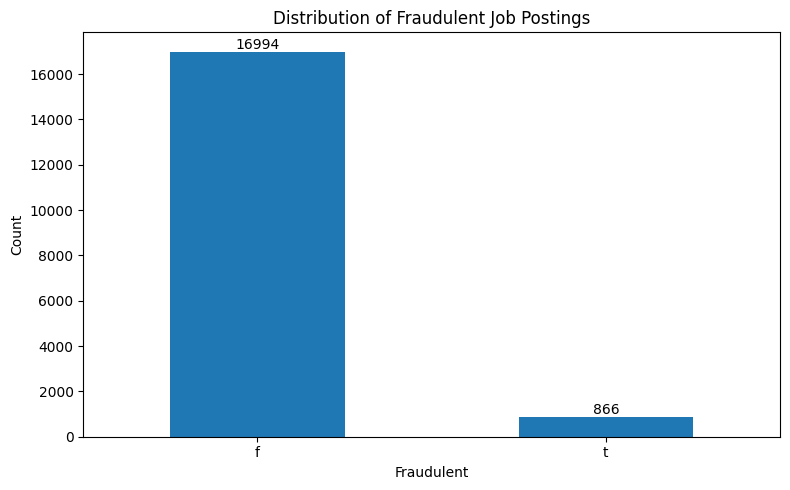

In [70]:
# Check target variable distribution (fraudulent vs non-fraudulent)
print(df['fraudulent'].value_counts())
print("\nProportions:")
print(df['fraudulent'].value_counts(normalize=True))

# Plot distribution
plt.figure(figsize=(8, 5))
ax = df['fraudulent'].value_counts().plot(kind='bar')
plt.xticks(rotation=0)
plt.title('Distribution of Fraudulent Job Postings')
plt.xlabel('Fraudulent')
plt.ylabel('Count')
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()


### Dataset: EMSCAD (Employment Scam Aegean Dataset)
**Source:** University of the Aegean | **Size:** 17,880 job ads (17,014 legitimate, 866 fraudulent) | **Period:** 2012–2014

All emails, phone numbers, and URLs in text fields were masked with hashed placeholders during annotation. This table was made upon general research and domain knowledge using the data source provided on the Kaggle website and other notebooks.

| Column | Type | Description |
|--------|------|-------------|
| `title` | Text | Job title as listed by the poster (e.g. "Marketing Intern", "Account Executive") |
| `location` | Text | Geographic location of the role in Country, State, City format (e.g. "US, NY, New York") |
| `department` | Text | Department within the company the role belongs to (e.g. "Sales", "Engineering") |
| `salary_range` | Text | Stated salary range for the role (e.g. "50000–80000") |
| `company_profile` | HTML Text | Background and description of the hiring company as written by the poster |
| `description` | HTML Text | Full job description including responsibilities and role details |
| `requirements` | HTML Text | Qualifications, skills, and experience required from applicants |
| `benefits` | HTML Text | Perks and benefits offered with the role |
| `telecommuting` | Binary (0/1) | Whether the role is offered as remote or work-from-home |
| `has_company_logo` | Binary (0/1) | Whether the posting includes an uploaded company logo |
| `has_questions` | Binary (0/1) | Whether the posting includes screening questions for applicants |
| `employment_type` | Categorical | Nature of employment (e.g. Full-time, Part-time, Contract, Temporary) |
| `required_experience` | Categorical | Level of experience required (e.g. Entry level, Mid-Senior level, Executive) |
| `required_education` | Categorical | Minimum education qualification required (e.g. Bachelor's Degree, High School) |
| `industry` | Categorical | Industry sector the role belongs to (e.g. Internet, Financial Services, Oil & Energy) |
| `function` | Categorical | Job function or area of work (e.g. Sales, Marketing, Engineering, Customer Service) |
| `fraudulent` | Binary (0/1) | Target variable — indicates whether the job posting is fraudulent (1) or legitimate (0) |
| `in_balanced_dataset` | Binary (0/1) | Dataset utility flag indicating whether the record was selected for a class-balanced subset |

In [71]:
# remove redundant column and print new shape (should be 17 columns now)
df = df.drop(columns=['in_balanced_dataset'])
print(df.shape)

(20434, 17)


## Quality of data

* Check for missing values — count and percentage per column, visualised as a bar chart sorted descending. Highlight which columns are severely sparse (>50%)

* Check for duplicates and conduct HTML tag check — confirm which text columns contain raw HTML (spot check a few cells)

* Cardinality of categoricals — utilise nunique() on employment_type, required_experience, required_education, industry, function to understand how many distinct values each has

                     Missing Count  Missing %
salary_range                 17510      85.69
department                   14022      68.62
required_education           10668      52.21
benefits                      9750      47.71
required_experience           9605      47.00
function                      9024      44.16
industry                      7470      36.56
employment_type               6020      29.46
company_profile               5823      28.50
requirements                  5238      25.63
location                      2770      13.56
fraudulent                    2574      12.60
has_company_logo              2557      12.51
has_questions                 2556      12.51
telecommuting                 2556      12.51
description                   2523      12.35


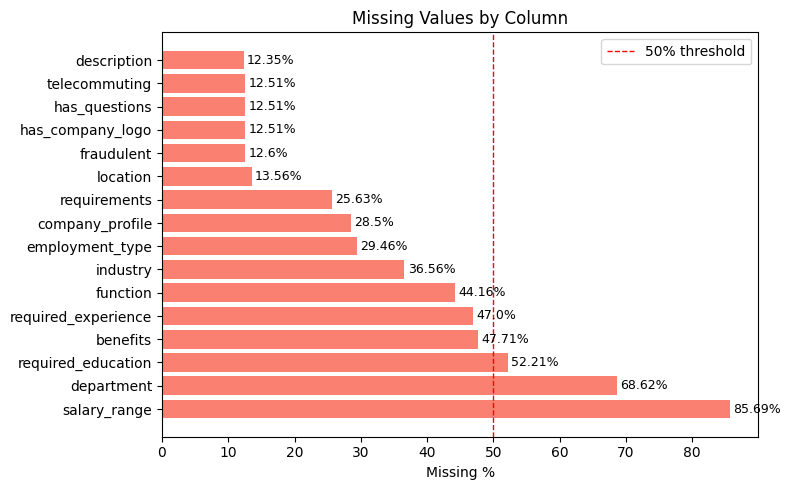

In [72]:
# Check for missing values
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing %', ascending=False)

missing = missing[missing['Missing Count'] > 0]
print(missing)

# Plot the missing value percentages
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(missing.index, missing['Missing %'], color='salmon')
ax.axvline(50, color='red', linestyle='--', linewidth=1, label='50% threshold')
ax.set_xlabel("Missing %")
ax.set_title("Missing Values by Column")
for bar, val in zip(bars, missing['Missing %']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val}%", va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

In [73]:
# check for HTML tags in text columns
html_cols = ['company_profile', 'description', 'requirements', 'benefits']

for col in html_cols:
    sample = df[col].dropna().iloc[0]
    has_tags = bool(BeautifulSoup(sample, "html.parser").find())
    print(f"{col}: {'Contains HTML tags ✓' if has_tags else 'No HTML tags detected'}")

company_profile: Contains HTML tags ✓
description: Contains HTML tags ✓
requirements: Contains HTML tags ✓
benefits: Contains HTML tags ✓


In [74]:
# check for cardinalities (number of unique values) in categorical columns
cat_cols = ['employment_type', 'required_experience', 
            'required_education', 'industry', 'function']

cardinality = pd.DataFrame({
    'Unique Values': [df[col].nunique() for col in cat_cols],
    'Sample Values': [df[col].dropna().unique()[:3].tolist() for col in cat_cols]
}, index=cat_cols)

# print the unique values
print(cardinality)

                     Unique Values  \
employment_type                  8   
required_experience             10   
required_education              14   
industry                       131   
function                        37   

                                                         Sample Values  
employment_type                          [Other, Full-time, Part-time]  
required_experience     [Internship, Not Applicable, Mid-Senior level]  
required_education   [Bachelor's Degree, Master's Degree, High Scho...  
industry             [Marketing and Advertising, Computer Software,...  
function                          [Marketing, Customer Service, Sales]  


## Limitations of Data

While the dataset provides a rather useful foundation for exploring generic job scam detection, several limitations should be noted:

**1. Heavy Class Imbalance** <br>
Only 5% of postings are labelled fraudulent (866 out of 17860). This means any model trained naively on this data will be biased toward predicting legitimate — achieving high accuracy while overlooking or wrongly classifying most scams since there is insufficient training data for the fraudlent (1) Boolean type. This class imbalance must be corrected before the data is used for any further analysis and must be done so very carefully. Assuming only this dataset is available, one method is oversampling the fraudulent data type (1) and undersampling the legitimate data type (0) until both are relatively equal in quantity. This is a common strategy to balance data. However, this can still introduce biasness in data as these sampling techniques typically utilise duplication of rows (usually at random selection). If this duplication is not done in a representative way, the model that is trained using this data may for example predict job postings for a healthcare department very well but fail to do the same for the IT industry. For this project context, it is assumed no extra new data is provided and thus the project falls onto the next best solution which is SMOTE and sampling.

**2. Large Amount of Missing Values** <br>
Several columns have missing rates exceeding 50% such as the `salary_range`, `department`, `benefits`, `required_education` columns. While missingness itself may carry some value (example: scam job postings may deliberately omit details), it significantly limits direct feature use without imputation or missingness indicators. To add on, a useful feature that could have been considered would be something similar to 'Process' or 'Verification type', where this column could have indicated simply if requests were made for sensitive information like bank details, NRICs etc without any physical contact. This might indicate trivial attempts at extracting private information to catch unaware job-seekers off guard, especially those who may not be as tech-savvy.

**3. Masked Contact Information** <br>
Based on the data source link, some emails, phone numbers, and URLs in text fields were replaced with hashed placeholders prior to publication. This removes potentially strong fraud signals such as suspicious personal email domains (e.g. Gmail instead of a company domain) or links to known scam websites that would be available in a real deployment setting.

**4. Temporal and Geographic Scope** <br>
The dataset covers job ads from 2012–2014, likely from a single Western job platform. Job scam tactics have evolved rapidly since then in the past decade, and the linguistic and structural patterns of scams targeting Singapore job seekers in 2026 also differ considerably. In the context of Singapore's cyber space, one recent and serious scam that has disrupted data privacy of job-seekers in Singapore, is the fraudulent seizing of Singpass account details. This is usually done so by scammers who impersonate employers to attempt to retrieve private information from job-seekers. In this aspect, the dataset does not appear to be very useful as there is no indication of whether Singpass retrieval was used. There are also only 26 observations of data where Singapore is the location.

**5. Manual Annotation Subjectivity** <br>
Fraudulent labels were assigned through human annotation. This introduces the possibility of labelling inconsistencies, especially for borderline cases where a posting may be misleading but not outright fraudulent.

**6. Unknown Platform Source** <br>
There is no metadata indicating which job platform or social media site each posting was scraped from. Platform-specific patterns (e.g. formatting norms, posting requirements) cannot be controlled for or leveraged as features.

## Features Potentially Useful for Identifying Fraudulent Postings

Based on initial exploration, the following feature groups are hypothesised to carry signal for fraud detection:

**Binary Flags**
`has_company_logo`, `has_questions`, and `telecommuting` are already structured signals. Legitimate employers are more likely to upload a logo and include screening questions. A disproportionate number of remote-only postings among scam ads would also be worth noting.

**Missingness as a Feature**
Scam ads may deliberately leave fields like `company_profile`, `benefits`, `salary_range`, and `required_education` empty to reduce effort or avoid scrutiny. The pattern of missing fields itself — not just the values — may distinguish fraud from legitimate postings.

**Salary Range**
Counterintuitively, scam ads may be *more* likely to state a salary than legitimate ones — often inflated figures used to attract victims. The presence and plausibility of `salary_range` is worth examining.

**Text-Based Features**
The four HTML text columns (`description`, `requirements`, `benefits`, `company_profile`) are likely the richest source of signal. After stripping HTML, features such as text length, vocabulary, and writing quality may differ between scam and legitimate ads. Scam ads may be unusually short, vague, or use copy-pasted boilerplate.

**Categorical Fields**
`employment_type`, `required_experience`, `required_education`, `industry`, and `function` may show skewed distributions among fraudulent postings — for example, scam ads may disproportionately target entry-level applicants or claim to be in high-demand industries.

In [75]:
# map target variable to 0 and 1
df['fraudulent'] = df['fraudulent'].map({'f': 0, 't': 1})
print(df['fraudulent'].value_counts())
print(df['fraudulent'].dtype)

fraudulent
0.0    16994
1.0      866
Name: count, dtype: int64
float64


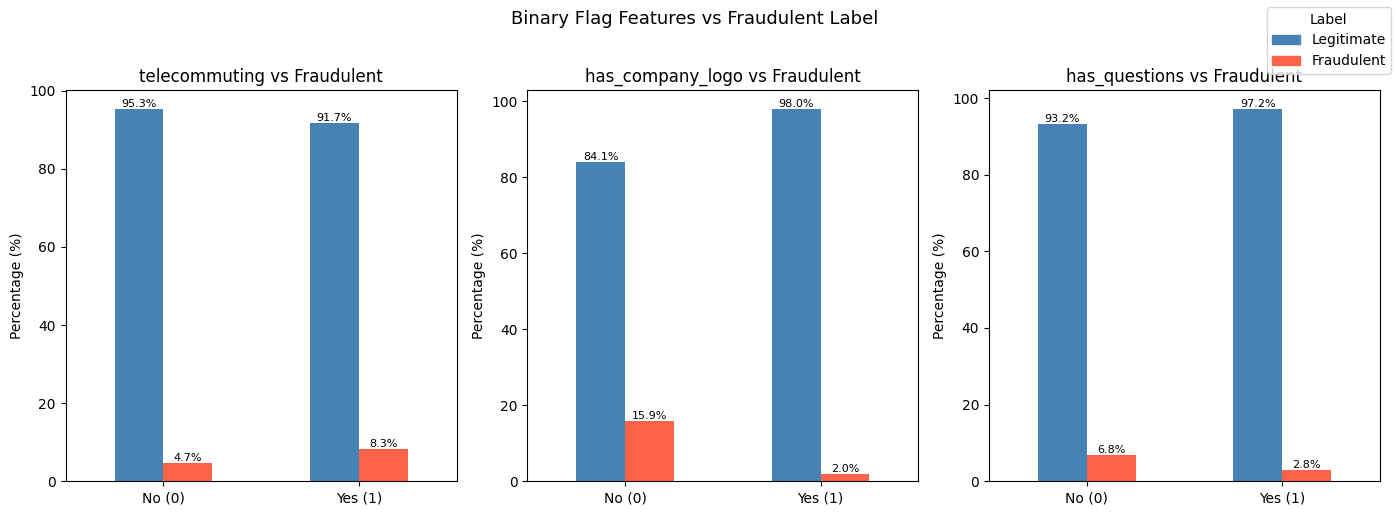

In [76]:
# ── Binary Flags vs Fraudulent ────────────────────────────────────
binary_cols = ['telecommuting', 'has_company_logo', 'has_questions']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col in zip(axes, binary_cols):
    ct = df.groupby([col, 'fraudulent']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'],
                legend=False, rot=0)
    ax.set_title(f'{col} vs Fraudulent')
    ax.set_xlabel('')
    ax.set_ylabel('Percentage (%)')
    ax.set_xticklabels(['No (0)', 'Yes (1)'])
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', fontsize=8)

handles = [plt.Rectangle((0,0),1,1, color='steelblue'),
           plt.Rectangle((0,0),1,1, color='tomato')]
fig.legend(handles, ['Legitimate', 'Fraudulent'],
           loc='upper right', title='Label')
plt.suptitle("Binary Flag Features vs Fraudulent Label", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Observations: Binary Flag Features vs Fraudulent Label

- **`has_company_logo`** is the strongest signal among the three flags. Posts *without* a logo have a 15.9% fraud rate, compared to only 2.0% for posts *with* a logo. Within the context of this dataset, legitimate employers are far more likely to upload a company logo, making its absence a meaningful red flag.

- **`has_questions`** shows a similar pattern — posts without screening questions have a higher fraud rate (6.8%) versus those with questions (2.8%). Scam postings likely skip screening questions as they are not genuinely hiring.

- **`telecommuting`** shows a modest but notable difference — remote postings have a slightly higher fraud rate (8.3%) compared to non-remote (4.7%). This aligns with the intuition that scam ads use remote work as bait to appear accessible and attractive to a wider pool of victims.

                     Legitimate  Fraudulent  Difference
company_profile           15.99       67.78       51.79
required_experience       38.88       50.23       11.35
employment_type           18.98       27.83        8.85
required_education        44.98       52.08        7.10
industry                  27.19       31.76        4.56
function                  35.97       38.91        2.94
requirements              14.92       17.67        2.74
benefits                  40.19       41.92        1.73
description                0.00        0.00        0.00
department                64.77       61.32       -3.45
salary_range              84.44       74.25      -10.19


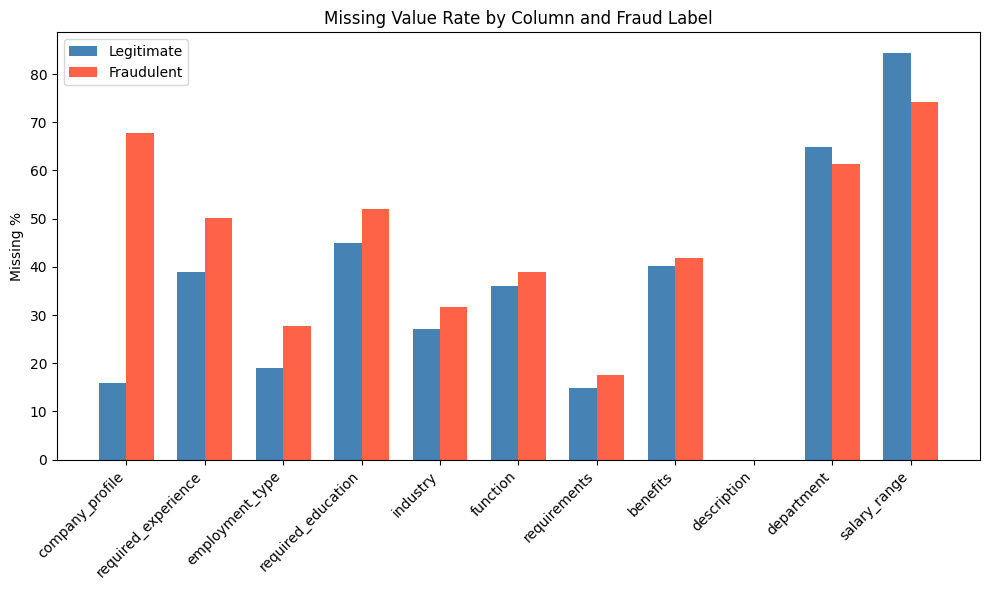

In [77]:
# ── Missingness Pattern by Fraudulent Label ───────────────────────
cols_to_check = ['company_profile', 'description', 'requirements',
                 'benefits', 'salary_range', 'department',
                 'employment_type', 'required_experience',
                 'required_education', 'industry', 'function']

missing_by_label = pd.DataFrame({
    'Legitimate': df[df['fraudulent'] == 0][cols_to_check].isnull().mean() * 100,
    'Fraudulent': df[df['fraudulent'] == 1][cols_to_check].isnull().mean() * 100
})
missing_by_label['Difference'] = (missing_by_label['Fraudulent'] 
                                   - missing_by_label['Legitimate']).round(2)
missing_by_label = missing_by_label.sort_values('Difference', ascending=False)
print(missing_by_label.round(2))

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(missing_by_label))
width = 0.35
ax.bar([i - width/2 for i in x], missing_by_label['Legitimate'],
       width, label='Legitimate', color='steelblue')
ax.bar([i + width/2 for i in x], missing_by_label['Fraudulent'],
       width, label='Fraudulent', color='tomato')
ax.set_xticks(list(x))
ax.set_xticklabels(missing_by_label.index, rotation=45, ha='right')
ax.set_ylabel('Missing %')
ax.set_title('Missing Value Rate by Column and Fraud Label')
ax.legend()
plt.tight_layout()
plt.show()

Observations: Missing Value Rate by Column and Fraud Label

- **`company_profile`** shows the starkest difference — fraudulent ads have a ~68% missing rate versus only ~16% for legitimate ads. Scammers frequently omit company background, likely because they have no real company to describe.

- **`required_experience`**, **`required_education`**, **`industry`**, and **`function`** all show consistently higher missingness in fraudulent ads. This suggests scam postings are deliberately vague — casting a wide net by not specifying who they are targeting.

- **`salary_range`** and **`department`** have high missing rates for *both* classes, making them less discriminative on missingness alone.

- **`description`** and **`requirements`** have near-zero missingness for both classes — scammers still fill in these fields, likely because a blank job description would immediately look suspicious.

- **Key insight:** The *pattern* of missing fields across a posting — not just any single field — may be a useful composite signal. Fraudulent ads tend to leave multiple structural fields empty simultaneously.

            No Salary Stated  Salary Stated
Legitimate             84.44          15.56
Fraudulent             74.25          25.75


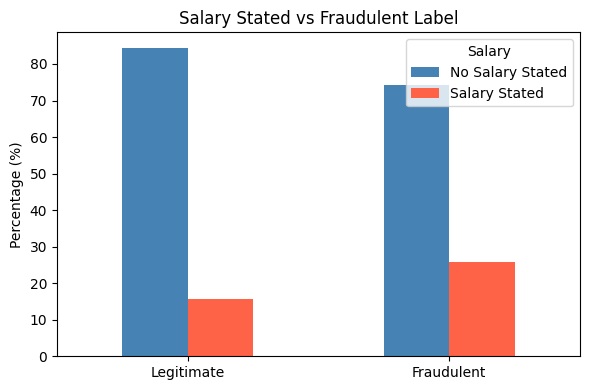

In [78]:
# ── Salary Range: Presence by Fraudulent Label ────────────────────
df['has_salary'] = df['salary_range'].notna().astype(int)

salary_ct = df.groupby(['fraudulent', 'has_salary']).size().unstack(fill_value=0)
salary_pct = salary_ct.div(salary_ct.sum(axis=1), axis=0) * 100
salary_pct.index = ['Legitimate', 'Fraudulent']
salary_pct.columns = ['No Salary Stated', 'Salary Stated']
print(salary_pct.round(2))

salary_pct.plot(kind='bar', color=['steelblue', 'tomato'],
                figsize=(6, 4), rot=0)
plt.title('Salary Stated vs Fraudulent Label')
plt.ylabel('Percentage (%)')
plt.legend(title='Salary')
plt.tight_layout()
plt.show()

Observations: Salary Stated vs Fraudulent Label

- Fraudulent postings are **more likely to state a salary** (~26%) compared to legitimate ones (~16%). This is counterintuitive but consistent with known scam behaviour — inflated or attractive salary figures are used as bait to lure applicants.

- This means the *presence* of a salary alone is not a reliable fraud indicator. The *plausibility* of the stated range (e.g. unrealistically high figures) would be more informative, but requires further analysis of the salary values themselves.

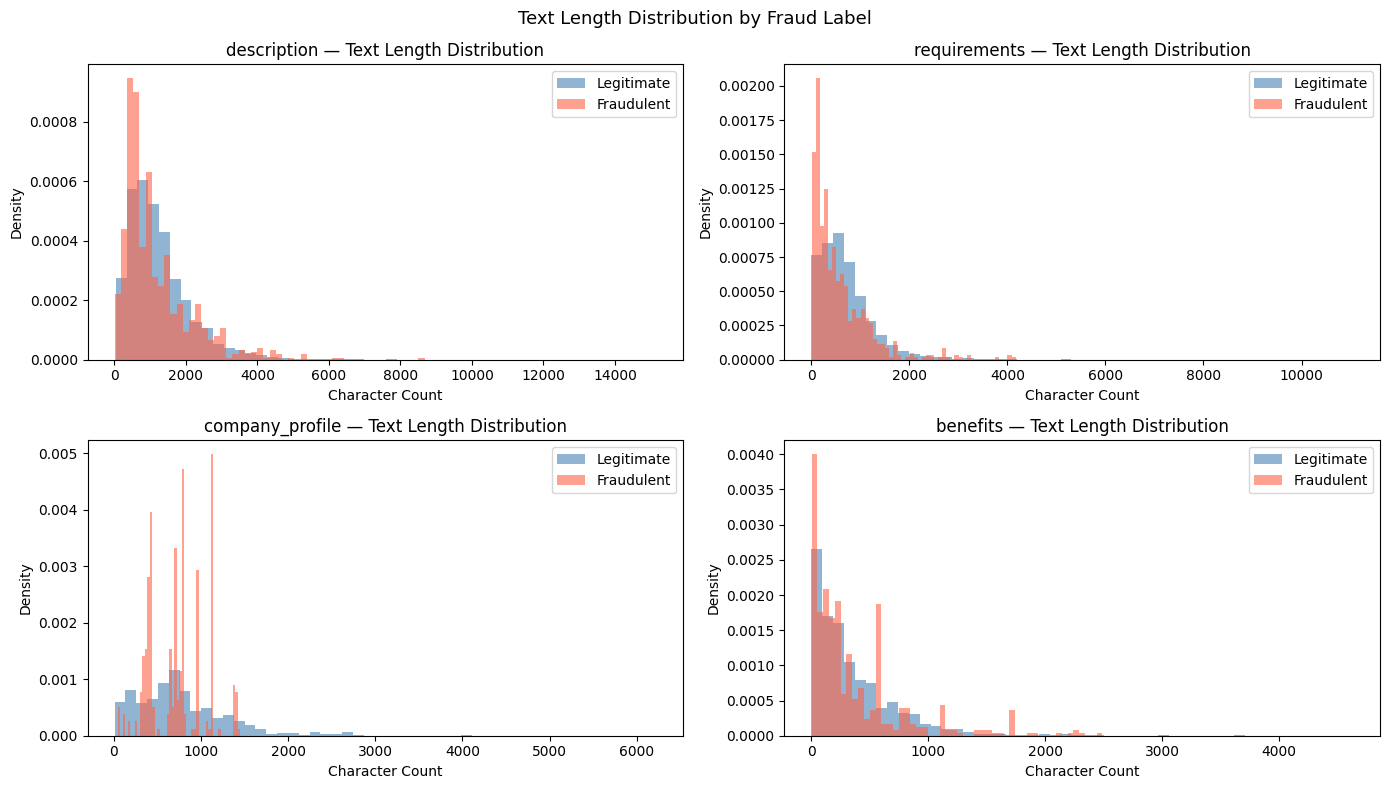

In [79]:
# ── Text Length Distribution by Fraudulent Label ──────────────────
def strip_html(text):
    if pd.isna(text):
        return ""
    return BeautifulSoup(text, "html.parser").get_text(separator=" ").strip()

text_cols = ['description', 'requirements', 'company_profile', 'benefits']

# Create length columns if they don't exist
for col in text_cols:
    if f'{col}_len' not in df.columns:
        df[f'{col}_clean'] = df[col].apply(strip_html)
        df[f'{col}_len']   = df[f'{col}_clean'].str.len()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, text_cols):
    for label, color, name in [(0, 'steelblue', 'Legitimate'),
                                (1, 'tomato', 'Fraudulent')]:
        data = df[df['fraudulent'] == label][f'{col}_len']
        data = data[data > 0]
        ax.hist(data, bins=50, alpha=0.6, color=color,
                label=name, density=True)
    ax.set_title(f'{col} — Text Length Distribution')
    ax.set_xlabel('Character Count')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle("Text Length Distribution by Fraud Label", fontsize=13)
plt.tight_layout()
plt.show()

A Note on Text Preprocessing Choices

**Why strip HTML tags**
HTML tags like `<p>`, `<h3>`, and `<ul>` are structural markup — they carry no semantic meaning about the job itself. Leaving them in would artificially inflate character counts and introduce noise that is purely an artefact of how the platform rendered the posting, not how the recruiter wrote it. For example, a posting with `<p><b>Job Description</b></p>` and one with just `Job Description` are identical in meaning but different in length if tags are not removed. Stripping them ensures measuring the actual content of the posting.

**Why keep symbols like ® and ™**
Trademark and copyright symbols are left in intentionally. Unlike HTML tags, they are part of the actual text content written by the poster. A legitimate company like "Microsoft®" may include such symbols as part of their branding, while a scam posting copying boilerplate text may reproduce them inconsistently or not at all. Removing them would destroy a subtle but potentially meaningful signal.

**What density means in the histogram**
Density is simply a rescaled version of frequency that allows fair comparison between two groups of very different sizes. In this dataset, there are roughly 17,000 legitimate ads but only 866 fraudulent ones. If raw counts are plotted, the fraudulent bars would be nearly invisible next to the legitimate ones. By using density, both distributions are rescaled so that the total area of each histogram sums to 1 — meaning the comparison is between the *shape* and *spread* of the distributions rather than their absolute sizes. A higher density at a given character count simply means a greater proportion of ads in that class fall around that length.

Observations: Text Length Distribution by Fraud Label

- **`description`**: Fraudulent ads skew heavily toward shorter descriptions (peak density below ~500 characters), while legitimate ads have a broader, more spread-out distribution extending to 4,000+ characters. Scam ads tend to be brief and vague.

- **`requirements`**: A very similar pattern — fraudulent ads spike sharply near zero, indicating many scam postings have minimal or no requirements stated. This aligns with the "cast a wide net" strategy of scammers.

- **`company_profile`**: The most visually noisy graph — fraudulent ads show multiple sharp spikes at short lengths, suggesting copy-pasted boilerplate text of fixed lengths being reused across postings. This is a strong signal of templated, non-genuine content.

- **`benefits`**: Both classes peak near zero due to high overall missingness, but fraudulent ads show a sharper spike, confirming they are more likely to leave benefits entirely blank.

- **Overall:** Shorter text length across multiple fields is a consistent signal of fraudulent postings. A composite feature combining text lengths across all four columns could be a useful engineered feature.

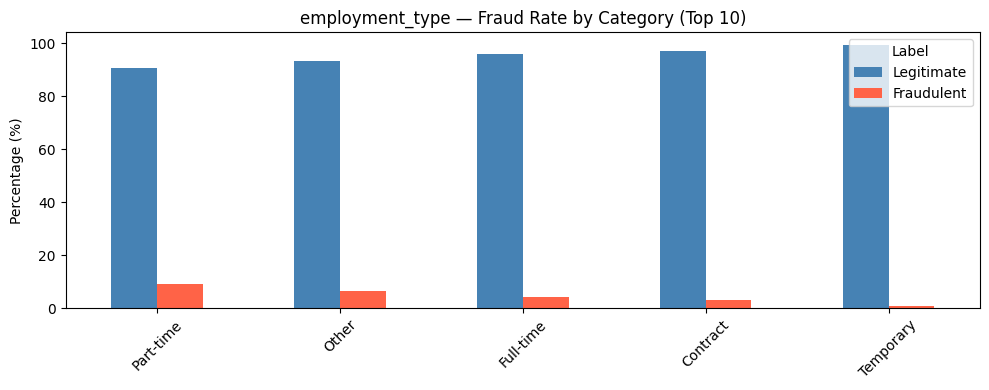

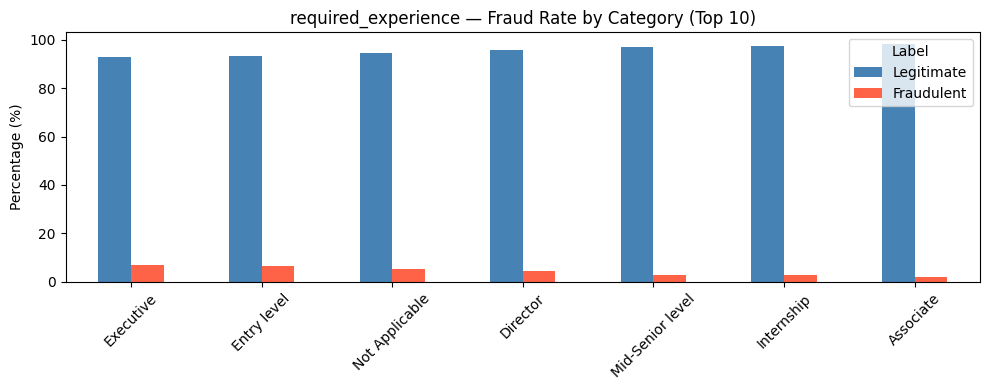

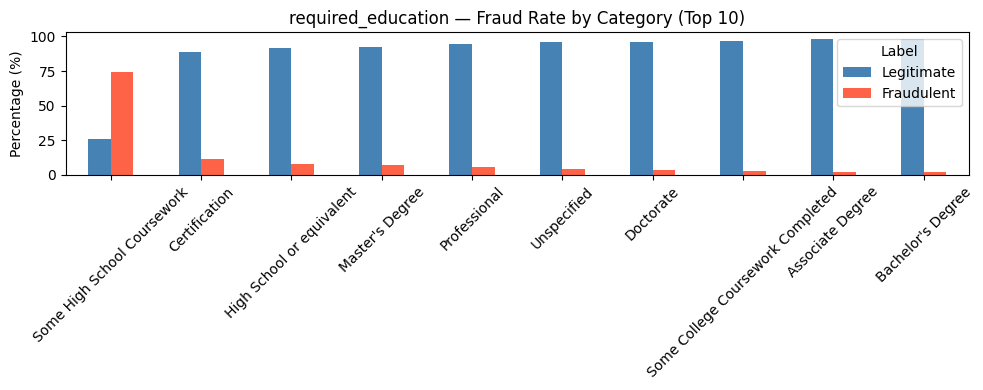

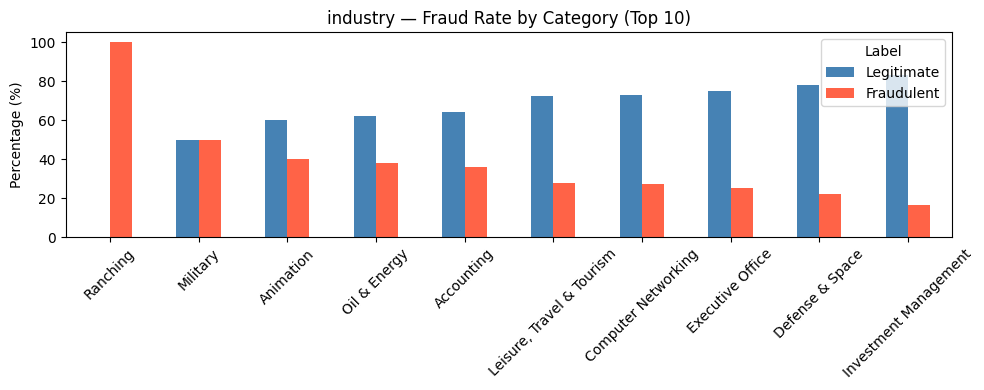

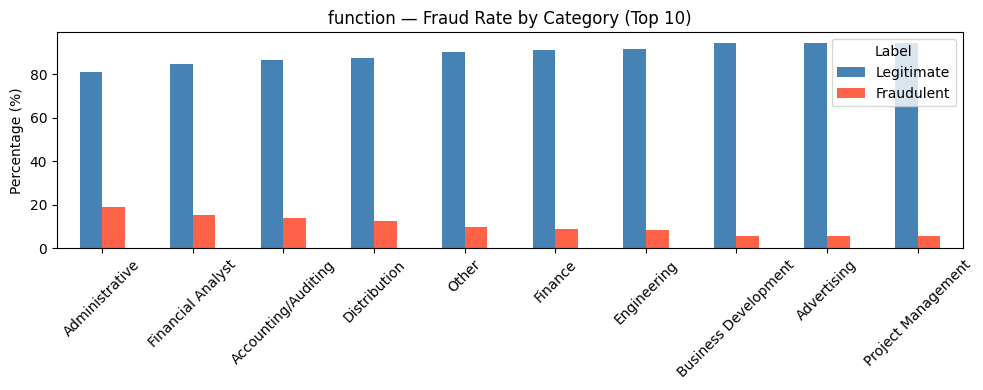

In [80]:
# ── Categorical Features vs Fraudulent Label ──────────────────────
cat_cols = ['employment_type', 'required_experience',
            'required_education', 'industry', 'function']

for col in cat_cols:
    ct = df.groupby([col, 'fraudulent']).size().unstack(fill_value=0)
    
    # Ensure both columns exist even if one label is missing for a category
    if 0 not in ct.columns:
        ct[0] = 0
    if 1 not in ct.columns:
        ct[1] = 0
    
    ct = ct[[0, 1]]
    ct.columns = ['Legitimate', 'Fraudulent']
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct = ct_pct.sort_values('Fraudulent', ascending=False).head(10)

    ct_pct.plot(kind='bar', color=['steelblue', 'tomato'],
                figsize=(10, 4), rot=45)
    plt.title(f'{col} — Fraud Rate by Category (Top 10)')
    plt.ylabel('Percentage (%)')
    plt.xlabel('')
    plt.legend(title='Label')
    plt.tight_layout()
    plt.show()

### Observations: Categorical Features vs Fraudulent Label

**Employment Type**
- `Part-time` postings have the highest fraud rate (~10%) among employment types, nearly double that of `Full-time` (~4.5%). This aligns with the intuition that scam ads targeting casual or desperate job seekers gravitate toward part-time roles.
- `Temporary` postings have the lowest fraud rate (~1.5%), possibly because temporary staffing is dominated by established agencies with structured processes.
- Overall, employment type shows moderate discriminative power — the differences exist but are not dramatic.

**Required Experience**
- `Executive` and `Entry level` postings share the highest fraud rates (~6–7%), which at first seems contradictory. However, this likely reflects two distinct scam strategies — impersonating prestigious senior roles to appear credible, and targeting inexperienced job seekers who are less likely to scrutinise postings carefully.
- `Internship` and `Associate` level postings have the lowest fraud rates, suggesting these categories are dominated by genuine institutional postings (universities, structured programmes).
- The differences across experience levels are relatively small, suggesting this feature alone has limited discriminative power.

**Required Education**
- `Some High School Coursework` stands out sharply — it has by far the highest fraud rate (~75%) with a very low legitimate rate (~25%). This is the strongest signal in this chart. Scam ads requiring minimal education cast the widest net, targeting the most vulnerable and least scrutinising applicants.
- `Certification` also shows an elevated fraud rate (~11%) compared to degree-level categories.
- Higher education requirements (`Bachelor's Degree`, `Master's Degree`, `Doctorate`) correspond to lower fraud rates, suggesting scammers avoid mimicking highly credentialed job postings as they require more convincing detail.
- **Key insight:** Required education level is a meaningful feature — lower education thresholds correlate with higher fraud rates.

**Industry**
- `Ranching` stands out dramatically — 100% of postings in this category are fraudulent. This is likely a data artefact from a very small sample size rather than a genuine industry-level pattern, and should be interpreted with caution.
- `Military` shows near-equal fraud and legitimate rates (~50/50), making it a notable high-risk category likely due to scammers impersonating defence-related roles.
- `Animation`, `Oil & Energy`, and `Accounting` all show elevated fraud rates (~35–40%), suggesting these are industries scammers commonly impersonate — possibly because they are associated with high salaries or are aspirational to job seekers.
- **Caveat:** Many of these high-fraud industries likely have very small sample sizes. Fraud rate alone without absolute counts can be misleading for rare categories.

**Function**
- `Administrative` (~19%), `Financial Analyst` (~15%), and `Accounting/Auditing` (~14%) have the highest fraud rates among job functions. These are roles that are easy to fabricate — they require generic skills and are in high demand.
- `Business Development`, `Advertising`, and `Project Management` show lower but still notable fraud rates (~5–6%).
- Unlike the industry chart, the function chart shows a more gradual decline across categories, suggesting job function is a moderately useful but not dominant feature on its own.
- **Key insight:** Administrative and finance-adjacent functions are disproportionately targeted, likely because they are common, accessible, and associated with decent pay — making them attractive bait.

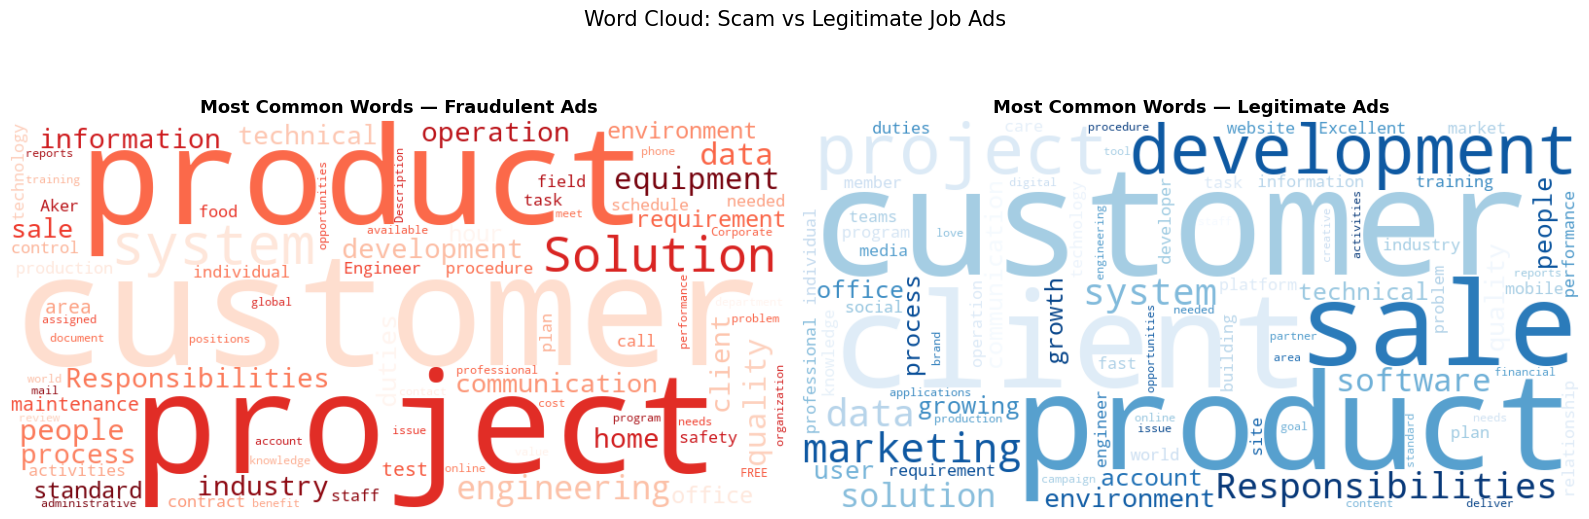

In [81]:
# display a word cloud

# Start with the built-in stopwords and aggressively extend
stopwords_custom = STOPWORDS.union({
    # Generic job ad words that appear in both classes equally
    'will', 'work', 'job', 'company', 'team', 'experience', 'position',
    'role', 'looking', 'working', 'opportunity', 'including', 'ability',
    'skills', 'years', 'strong', 'provide', 'required', 'must', 'new',
    'using', 'well', 'also', 'within', 'across', 'based', 'ensure',
    'support', 'responsible', 'candidate', 'candidates', 'employer',
    'employees', 'need', 'help', 'good', 'great', 'best', 'high',
    'make', 'use', 'used', 'able', 'part', 'full', 'time', 'one',
    'two', 'three', 'four', 'five', 'year', 'day', 'week', 'month',
    # Sentence fragments showing up as phrases
    'we', 'are', 'you', 'our', 'your', 'us', 'we re', 'you ll',
    'this', 'that', 'they', 'them', 'their', 'these', 'those',
    'have', 'has', 'had', 'been', 'being', 'get', 'got', 'take',
    'want', 'know', 'think', 'come', 'go', 'see', 'look', 'way',
    # Prepositions and connectors still slipping through
    'with', 'for', 'and', 'the', 'of', 'in', 'on', 'at', 'to',
    'from', 'by', 'an', 'as', 'is', 'it', 'be', 'or', 'not',
    'if', 'but', 'all', 'any', 'more', 'than', 'such', 'each',
    'other', 'into', 'about', 'up', 'out', 'so', 'do', 'did',
    # Common business filler
    'services', 'service', 'business', 'management', 'manager',
    'senior', 'level', 'entry', 'associate', 'director', 'officer',
    'candidate', 'hire', 'hiring', 'apply', 'application', 'please',
    'join', 'seek', 'seeking', 'offer', 'offering', 'minimum',
    'preferred', 'equivalent', 'related', 'relevant', 'following',
    'include', 'includes', 'included', 'develop', 'maintain',
    'coordinate', 'assist', 'perform', 'perform', 'report',
    'develop', 'design', 'build', 'create', 'manage', 'lead'
})

# Combine all description_clean text by label
fraud_text = ' '.join(df[df['fraudulent'] == 1]['description_clean'].dropna())
legit_text = ' '.join(df[df['fraudulent'] == 0]['description_clean'].dropna())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_fraud = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Reds',
    stopwords=stopwords_custom,
    max_words=80,
    collocations=False,      # prevents duplicate word pairs
    min_word_length=4        # filters out short filler words like 'an', 'if'
).generate(fraud_text)

axes[0].imshow(wc_fraud, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Most Common Words — Fraudulent Ads', fontsize=13, fontweight='bold')

wc_legit = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Blues',
    stopwords=stopwords_custom,
    max_words=80,
    collocations=False,
    min_word_length=4
).generate(legit_text)

axes[1].imshow(wc_legit, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Most Common Words — Legitimate Ads', fontsize=13, fontweight='bold')

plt.suptitle('Word Cloud: Scam vs Legitimate Job Ads', fontsize=15)
plt.tight_layout()
plt.show()

Note: Most words are rather similar such as 'project', 'customer' etc but there are some distinct words worth taking note of in fraudulent ads such as 'free', 'benefit', 'mail' and 'contact'. These are not found in the word cloud of the legitimate ads.

In [82]:
# ── Count of Unique Values: Industry & Required Education ──────────────────
for col in ['industry', 'required_education']:
    print(f"\n{'='*50}")
    print(f"{col} — {df[col].nunique()} unique values")
    print('='*50)
    print(df[col].value_counts(dropna=False).to_string())


industry — 131 unique values
industry
NaN                                     7470
Information Technology and Services     1734
Computer Software                       1375
Internet                                1062
Marketing and Advertising                828
Education Management                     822
Financial Services                       779
Hospital & Health Care                   497
Consumer Services                        357
Telecommunications                       334
Oil & Energy                             287
Retail                                   222
Real Estate                              175
Accounting                               159
Construction                             158
E-Learning                               139
Management Consulting                    130
Design                                   129
Health, Wellness and Fitness             127
Staffing and Recruiting                  127
Insurance                                123
Automotive      

Note: The very last line "look for leverage and demonstrate..." is an indication of erroneous data where data of one column leaked into the next. This will be addressed later during cleaning and enriching.

## Summary of Feature Usefulness

**Most Useful Features**
- `has_company_logo` — strongest single signal; absence strongly associated with fraud
- `company_profile` (missingness + text length) — fraudulent ads frequently omit or use very short boilerplate company descriptions
- `required_education` — low education thresholds (e.g. Some High School) strongly correlate with fraud
- Text length across `description`, `requirements`, `benefits` — fraudulent ads are consistently shorter
- `function` and `industry` — certain categories (Administrative, Financial Analyst, Military, Oil & Energy) are disproportionately targeted

**Moderately Useful Features**
- `has_questions`, `telecommuting` — show directional signal but differences are modest
- `employment_type`, `required_experience` — some variation across categories but not strongly discriminative alone
- `salary_range` presence — fraudulent ads more likely to state a salary, but requires plausibility analysis to be actionable

**Least Useful Features**
- `department`, `location` — high missingness across both classes, low discriminative value

---

## Recurring Patterns and Signals

1. **Deliberate vagueness** — Scam ads systematically leave structural fields empty (`company_profile`, `required_education`, `industry`) while maintaining a surface-level description, striking a calculated balance between effort and deception

2. **Wide net targeting** — Low or no education/experience requirements, part-time roles, and remote work postings are used to maximise the pool of potential victims

3. **Salary as bait** — Fraudulent ads are more likely to state a salary than legitimate ones, consistent with social engineering tactics using inflated figures to attract victims quickly

4. **Templated content** — Fixed-length spikes in `company_profile` text length suggest scammers reuse boilerplate text across multiple postings

5. **Impersonation of aspirational roles** — High-pay industries (Oil & Energy, Military, Finance) and accessible functions (Administrative, Financial Analyst) are disproportionately mimicked

In [83]:
# check info of modified dataframe
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20434 entries, 0 to 20433
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  20434 non-null  object 
 1   location               17664 non-null  object 
 2   department             6412 non-null   object 
 3   salary_range           2924 non-null   object 
 4   company_profile        14611 non-null  object 
 5   description            17911 non-null  object 
 6   requirements           15196 non-null  object 
 7   benefits               10684 non-null  object 
 8   telecommuting          17878 non-null  object 
 9   has_company_logo       17877 non-null  object 
 10  has_questions          17878 non-null  object 
 11  employment_type        14414 non-null  object 
 12  required_experience    10829 non-null  object 
 13  required_education     9766 non-null   object 
 14  industry               12964 non-null  object 
 15  fu

## Engineered & Derived Columns

The following columns were created during preprocessing and analysis. They are not part of the original dataset.

| Column | Derived From | Description |
|--------|-------------|-------------|
| `has_salary` | `salary_range` | Binary indicator — 1 if salary range was stated, 0 if missing |
| `description_clean` | `description` | HTML-stripped plain text version of the job description |
| `requirements_clean` | `requirements` | HTML-stripped plain text version of the job requirements |
| `company_profile_clean` | `company_profile` | HTML-stripped plain text version of the company profile |
| `benefits_clean` | `benefits` | HTML-stripped plain text version of the benefits field |
| `description_len` | `description_clean` | Character count of the cleaned job description |
| `requirements_len` | `requirements_clean` | Character count of the cleaned job requirements |
| `company_profile_len` | `company_profile_clean` | Character count of the cleaned company profile |
| `benefits_len` | `benefits_clean` | Character count of the cleaned benefits text |

# Approach
A hybrid approach is involving a structured, feature-based Random Forest and Term Frequency-Inverse Document Frequency (TF-IDF) + Logistic Regression to derive a NLP score. The `description_clean` column is vectorized using TF-IDF to capture *what* the ad says. A Logistic Regression model converts this into a single fraud probability score (`nlp_fraud_score`) which is passed into the Random Forest as an additional feature. This technique is known as **Late Fusion** or **Model Stacking** — it allows the Random Forest to weigh linguistic suspicion alongside structural signals without requiring a complex end-to-end NLP model. This method that is implemented in an ETL pipeline class has a balance of cost, effectiveness and easy explanability to stakeholders.


### Dilemma of cleaning process and feature engineering:

In many data science projects, the common strategy for ensuring data quality is to immediately fill in missing values and drop columns that do not appear to have high correlation with the target variable in binary classifications. However, taking this approach in this project context is not the best idea and will even result in unrepresentative data.

Instead, feature engineering should come first with some cleaning. Missing values are signals not noise, as mentioned in the EDA above, which provide indications of whether a job posting is fake or not. Filling these missing values without analysis is removing the traces of a scammer's doings. Next, balancing the target variable using SMOTE or over/under sampling (as previously mentioned) before feature selection is not ideal. This will risk overfitting and mixes the test data with training data for modelling later on, which defeats the whole purposes of keeping the test and training data separate.

### ETL (Extract, Transform, Load) Data Pipeline Solution:
In order to ensure the data is clean, fair, useful and balanced, the following steps are taken:

Data Cleaning --> Feature Engineering --> Split Data into Train and Test --> Balance the training data using SMOTE and random undersampling --> Reassess feature importance using Random Forest

### Core Assumptions
1) Schema Adherence: Assume that future batch data (CSVs) will follow the established EMSCAD schema (same column names and data types).

2) Scraper Consistency: Assume the upstream scraping methodology remains constant. However, the pipeline is built modularly so that if the data leakage patterns change (example: look for leverage and demonstrate persistence...), only the cleaning functions need to be updated.

3) Feature Signal Persistence: Assume that the correlation between "Missingness/Vagueness" and "Fraudulent Intent" observed in EDA is a fundamental characteristic of this dataset, justifying the data enriching by making new features.

### Dataset Preparation: Full Column Action Plan

| Column | Action | Logic / Justification |
|--------|--------|-----------------------|
| `title` | Keep | Used to derive `has_remote_keywords`. Kept raw for future NLP |
| `location`, `department` | Drop | With reference to EDA, large number of missing values across fraud and non-fraud classes (not very useful) |
| `company_profile`, `description`, `requirements`, `benefits` (raw HTML) | Drop | Redundant — signals already extracted into `_clean` and `_len` columns. Drop ONLY after enrichment |
| `telecommuting`, `has_company_logo`, `has_questions` | Keep | With reference to EDA, high quality binary flags |
| `employment_type`, `required_experience`, `required_education`, `industry`, `function` | Clean — standardize, fill NaNs with `"Unspecified"` | Ensures model stability. Fixes scraper-corrupted strings (e.g. "Persistence" row) in `required_education` |
| `fraudulent` | Target — drop NaN rows, cast to integer | Rows with missing labels cannot contribute to supervised training |
| `has_salary` | Keep | Already derived from `salary_range`. Strong transparency signal |
| `description_clean`, `requirements_clean`, `company_profile_clean`, `benefits_clean` | Keep | Sanitized text ready for future keyword or sentiment analysis |
| `description_len`, `requirements_len`, `company_profile_len`, `benefits_len` | Keep | Foundational numerical length metrics for structural anomaly detection |
| `missing_data_score` | Enrich | Sum of NaNs across `company_profile`, `department`, `industry`, `required_education` — Captures the accumulated lack of professional detail, which is a stronger signal than any single missing field |
| `desc_to_profile_ratio` | Enrich | `description_len / (company_profile_len + 1)` — Detects impersonation pattern of long descriptions with no company background |
| `masked_url_count` | Enrich | Count of `#URL#` in `description` — Large number of masked URLS may indicate phishing attempts |
| `masked_contact_count` | Enrich | Count of `#EMAIL#` and `#PHONE#` across text fields — Flags attempt to transfer victims off-platform to scam websites/trick them to release emails, NRICs, Singpass etc |
| `is_high_risk_industry` | Enrich | Binary flag for Oil & Energy, Accounting, Computer Networking — Scammers may strategically target specific industries, this flag marks which are at higher risks based on reasonable data volume (with reference to EDA, examples like military are rejected since there are only 2 instances; this insufficiency of data is not ideal for training). |
| `is_low_edu_req` | Enrich | Binary flag for Unspecified, High School, or Certification education — Low barriers used to trick job-seekers trying to get entry-level jobs or those who are less aware/educated |
| `has_remote_keywords` | Enrich | Binary search for "Remote", "WFH", "Work from home" in `title` — Scammers may use 'remote' work to bait job-seekers |

Detailed Steps:
1) Drop rows with missing fraudulent labels.

2) Calculate missing_data_score while the dataframe is still "messy."

3) Count #URL#, #EMAIL#, and #PHONE# instances within the raw text columns.

4) Create has_remote_keywords from the title.

5) Run .fillna("Unspecified") and fix the "Persistence" corrupted strings for categorical columns.

6) Create is_high_risk_industry and is_low_edu_req.

7) Drop the raw HTML columns of company_profile, description, requirements, benefits and categorical columns of location, department and salary_range since the enriched columns are more ideal.

8) Split into Training data and Test data (80-20), then use SMOTE and sampling to rebalance the training.

9) Feed data into Random Forest Classifier and assess for suitability using metrics.

10) Generate NLP Fraud Score (Late Fusion / Model Stacking):
    After the structured Random Forest pilot, a lightweight NLP signal is generated from the `description_clean` column using TF-IDF vectorization and Logistic Regression.
    - TF-IDF converts the cleaned job description text into a numerical matrix, weighting words that are rare across the dataset but frequent within a specific posting (e.g. "urgent", "guaranteed", "investment").

    - A Logistic Regression model is used on this matrix using the same 80-20 stratified split to prevent data leakage — the vectorizer is fitted only on training text, then applied to the full dataset.

    - The output `nlp_fraud_score` (a probability between 0 and 1) is added as a new feature column, representing how linguistically suspicious a posting is based on word patterns alone.

    - This score is then passed into the Random Forest as an additional feature, combining structural signals ("how the ad is built") with linguistic signals ("what the ad says") — a technique known as Late Fusion or Model Stacking.

    - The top TF-IDF weighted words most indicative of fraud are also surfaced, providing explainability for downstream analysts.

Starting Pipeline. Initial shape: (20434, 18)
Duplicates removed: 235
Post-Enrichment Shape: (17625, 27)

Generating NLP fraud score...

--- NLP Pilot (TF-IDF + Logistic Regression) ---
              precision    recall  f1-score   support

  Legitimate       0.99      0.96      0.97      3353
  Fraudulent       0.46      0.73      0.57       172

    accuracy                           0.95      3525
   macro avg       0.72      0.84      0.77      3525
weighted avg       0.96      0.95      0.95      3525


--- Top 15 Words Most Indicative of Fraud ---
       Word  TF-IDF Weight
       link       5.989843
  work home       4.134839
engineering       4.098033
      money       3.922068
    weather       3.611241
     subsea       3.573779
  assistant       3.373505
 data entry       3.318920
        400       3.123522
      clerk       3.101879
 accountant       2.940166
      entry       2.870071
     income       2.852828
   clerical       2.849003
     skills       2.837430

nlp_fra

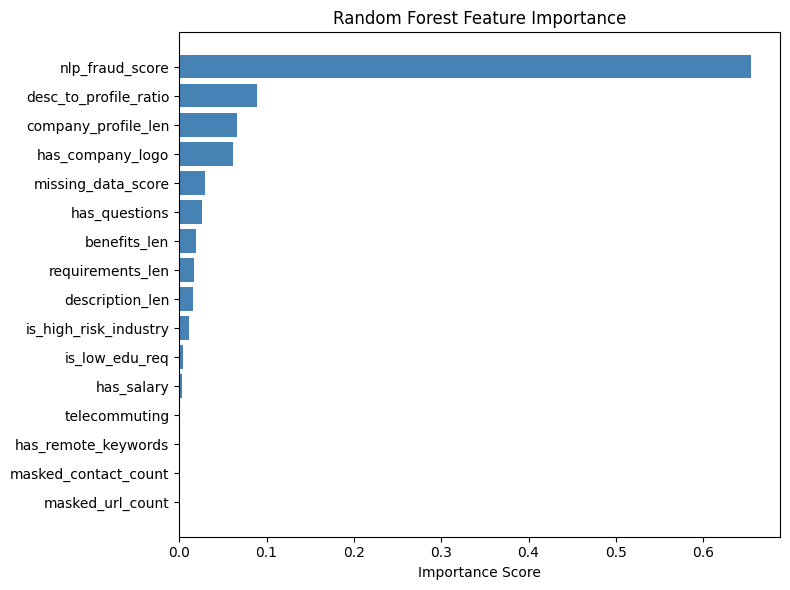

In [84]:
# ETL Pipeline

class GASP_JobScamPipeline:
    def __init__(self):
        self.high_risk_industries = ['Oil & Energy', 'Accounting', 'Computer Networking']
        self.low_edu_reqs         = ['Unspecified', 'High School or equivalent', 'Certification']
        self.raw_text_cols        = ['description', 'company_profile', 'requirements', 'benefits']

    # function to strip HTML tags
    def _strip_html(self, text):
        if pd.isna(text):
            return ""
        return BeautifulSoup(str(text), "html.parser").get_text(separator=" ").strip()

    def clean_and_enrich(self, df):
        print(f"Starting Pipeline. Initial shape: {df.shape}")

        # step 1:
        # Map target variable to 0 and 1, drop rows with invalid label
        df['fraudulent'] = df['fraudulent'].map({'f': 0, 't': 1})
        df = df.dropna(subset=['fraudulent']).copy()

        # drop exact duplicate rows
        before = len(df)
        df = df.drop_duplicates()
        after = len(df)
        print(f"Duplicates removed: {before - after}")
        df['fraudulent'] = df['fraudulent'].astype(int)

        # Assign 0 or 1 to binary flags
        for col in ['telecommuting', 'has_company_logo', 'has_questions']:
            df[col] = df[col].map({'f': 0, 't': 1}).fillna(0).astype(int)

        # strip HTML tags and return clean version with length
        for col in self.raw_text_cols:
            df[f'{col}_clean'] = df[col].apply(self._strip_html)
            df[f'{col}_len']   = df[f'{col}_clean'].str.len()

        df['has_salary'] = df['salary_range'].notnull().astype(int)

        # Step 2: Derive sum of missing values
        vagueness_cols = ['company_profile', 'department', 'industry', 'required_education']
        df['missing_data_score'] = df[vagueness_cols].isnull().sum(axis=1)

        # Step 3: Count number of masked URLs and contact info tags
        df['masked_url_count'] = df['description'].fillna('').str.count('#URL#').astype(int)
        df['masked_contact_count'] = 0
        for col in self.raw_text_cols:
            df['masked_contact_count'] += df[col].fillna('').str.count('#EMAIL#|#PHONE#').astype(int)

        # Step 4: Binary flag for whether remote keyword present in title
        df['has_remote_keywords'] = df['title'].str.contains(
            'Remote|WFH|Work from home', case=False, na=False).astype(int)

        # Step 5: Fill missing values with 'Unspecified' for categorical columns
        valid_edu = ["Bachelor's Degree", "High School or equivalent", "Unspecified",
                     "Master's Degree", "Associate Degree", "Certification"]
        df['required_education'] = df['required_education'].apply(
            lambda x: x if x in valid_edu else 'Unspecified')

        cat_cols = ['employment_type', 'required_experience',
                    'required_education', 'industry', 'function']
        df[cat_cols] = df[cat_cols].fillna('Unspecified')

        # Step 6: Create flags for high-risk industries and low education requirements
        df['is_high_risk_industry'] = df['industry'].isin(self.high_risk_industries).astype(int)
        df['is_low_edu_req']        = df['required_education'].isin(self.low_edu_reqs).astype(int)
        df['desc_to_profile_ratio'] = df['description_len'] / (df['company_profile_len'] + 1)

        # Step 7: Drop raw columns
        cols_to_drop = self.raw_text_cols + ['salary_range', 'location', 'department']
        df = df.drop(columns=cols_to_drop)

        print(f"Post-Enrichment Shape: {df.shape}")
        return df

    def generate_nlp_score(self, df):
        """
        TF-IDF on description_clean → Logistic Regression → nlp_fraud_score.
        Trains on 80% of data, scores entire dataframe.
        Score represents the probability of a posting being fraudulent
        based on linguistic patterns alone.
        """
        print("\nGenerating NLP fraud score...")

        # Split to avoid data leakage — fit TF-IDF only on training text
        X_text = df['description_clean']
        y      = df['fraudulent']

        X_train_text, X_test_text, y_train, y_test = train_test_split(
            X_text, y, test_size=0.2, random_state=42, stratify=y)

        # TF-IDF Vectorization
        tfidf = TfidfVectorizer(
            max_features=5000,    # top 5000 most informative words
            stop_words='english', # remove common English stopwords
            ngram_range=(1, 2)    # include single words and two-word phrases
        )
        X_train_tfidf = tfidf.fit_transform(X_train_text)
        X_test_tfidf  = tfidf.transform(X_test_text)

        # Logistic Regression
        lr = LogisticRegression(
            class_weight='balanced', # handles imbalance automatically
            max_iter=1000,
            random_state=42
        )
        lr.fit(X_train_tfidf, y_train)

        # NLP pilot evaluation
        y_pred_nlp = lr.predict(X_test_tfidf)
        print("\n--- NLP Pilot (TF-IDF + Logistic Regression) ---")
        print(classification_report(y_test, y_pred_nlp,
                                    target_names=['Legitimate', 'Fraudulent']))

        # Score entire dataframe and add as feature
        X_all_tfidf          = tfidf.transform(X_text)
        df['nlp_fraud_score'] = lr.predict_proba(X_all_tfidf)[:, 1]

        # Show top fraud-indicative words
        feature_names = tfidf.get_feature_names_out()
        coefs         = lr.coef_[0]
        top_fraud_words = pd.DataFrame({
            'Word'      : feature_names,
            'TF-IDF Weight': coefs
        }).sort_values('TF-IDF Weight', ascending=False).head(15)

        print("\n--- Top 15 Words Most Indicative of Fraud ---")
        print(top_fraud_words.to_string(index=False))

        print(f"\nnlp_fraud_score added. Score range: "
              f"{df['nlp_fraud_score'].min():.3f} – {df['nlp_fraud_score'].max():.3f}")
        return df

    def run_pilot_and_reassess(self, df):
        """Splits data, balances training set, trains Random Forest."""

        features = [
            'telecommuting', 'has_company_logo', 'has_questions', 'has_salary',
            'description_len', 'requirements_len', 'company_profile_len', 'benefits_len',
            'missing_data_score', 'desc_to_profile_ratio', 'masked_url_count',
            'masked_contact_count', 'is_high_risk_industry', 'is_low_edu_req',
            'has_remote_keywords',
            'nlp_fraud_score'       # ← NLP signal metric added here
        ]

        X = df[features]
        y = df['fraudulent']

        # 1. Stratified Split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y)

        # 2. SMOTE on training set only
        smote = SMOTE(sampling_strategy=0.5, random_state=42)
        X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

        print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
        print(f"After SMOTE:  {pd.Series(y_train_bal).value_counts().to_dict()}")

        # 3. Train Random Forest
        rf = RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1,
            class_weight={0: 1, 1: 3}
        )
        rf.fit(X_train_bal, y_train_bal)

        # 4. Evaluation
        y_pred = rf.predict(X_test)
        print("\n--- Final Pilot Classification Report (RF + NLP Score) ---")
        print(classification_report(y_test, y_pred,
                                    target_names=['Legitimate', 'Fraudulent']))

        # 5. Feature Importance
        importance_df = pd.DataFrame({
            'Feature'   : features,
            'Importance': rf.feature_importances_
        }).sort_values('Importance', ascending=False)

        print("\n--- Feature Importance ---")
        print(importance_df.to_string(index=False))

        # Plot feature importance
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.barh(importance_df['Feature'][::-1],
                importance_df['Importance'][::-1],
                color='steelblue')
        ax.set_title('Random Forest Feature Importance')
        ax.set_xlabel('Importance Score')
        plt.tight_layout()
        plt.show()

        return rf, importance_df


# Execute the pipeline
raw_df         = pd.read_csv('job_postings.csv')
gasp_pipeline  = GASP_JobScamPipeline()
final_df       = gasp_pipeline.clean_and_enrich(raw_df)
final_df       = gasp_pipeline.generate_nlp_score(final_df)
model, importance_df = gasp_pipeline.run_pilot_and_reassess(final_df)

### Note on Pilot Model Performance

As per project instructions, this pilot is not intended to be a production-ready model. The dataset is heavily imbalanced (~5% fraud), and the features used are purely numerical derivations from EDA.

SMOTE is applied at a basic level (`sampling_strategy=0.5`) to partially address the imbalance without over-synthesising minority examples, which would risk overfitting on artificial data. In a real deployment, further tuning of the sampling strategy, feature set, and decision threshold would be required.

The primary purpose of this pilot is to validate that the engineered features carry meaningful signal and to show that the ETL pipeline works as a filter before using expensive NLP models. In a real scenario, the ETL pipeline can be fed more balanced data and tuned to have better metrics.

### Evaluation of Metrics, Validation Methods or Baselines

**Why accuracy is not the right metric**
With ~95% legitimate ads, a naive model that predicts every posting as legitimate achieves 95% accuracy while catching zero scams. Accuracy is therefore misleading and should not be used as the primary evaluation metric.

**Primary Metric — Recall (Sensitivity)**
Recall measures the proportion of actual scams that the model correctly identifies. In a job scam detection context, a missed scam (false negative) is more harmful than a false alarm (false positive) — a victim of a scam faces real financial and personal harm, while a legitimate ad being flagged for review is a minor inconvenience (ethics of this can be discussed further). Recall on the fraudulent class should therefore be maximised.

**Secondary Metric — Precision**
Precision measures how many of the model's fraud predictions are correct. Very low precision means human reviewers are overwhelmed with false alarms, reducing operational trust in the system. A balance between recall and precision is captured by the **F1-Score**.

**Supporting Metrics**
- **F1-Score (Fraudulent class)** — harmonic mean of precision and recall; primary summary metric
- **AUC-ROC** — measures the model's ability to distinguish between classes across all thresholds; useful for threshold selection
- **Precision-Recall AUC** — more informative than ROC-AUC under heavy class imbalance

**Baseline Comparisons**
The pilot model should be benchmarked against:

| Baseline | Description |
|----------|-------------|
| Majority class classifier | Predicts legitimate for every posting — sets the floor |
| Rule-based heuristic | Flag any posting missing `has_company_logo` AND `company_profile` — a simple but interpretable benchmark |
| Structured features only (Random Forest, no NLP score) | Checks if the `nlp_fraud_score` feature actually makes any significant contribution to prediction metrics|
| NLP only (TF-IDF + LR) | Checks if the structured features actually make any significant contribution to prediction metrics |
| List of Top words used in fraudulent postings | When checking actual postings, flag out the posting if it contains these words |

**Validation Method**
A single 80-20 stratified split is used for this pilot given the dataset size. In a production setting, k-fold cross-validation (k=5) with stratification would be preferred to reduce variance in performance estimates.

## Challenges and Limitations of Proposed Approach

**1. Dataset Temporal Gap**
The training data is from 2012–2014. Scam tactics have evolved significantly — modern job scams on platforms like Telegram, LinkedIn, or Jobstreet use different linguistic patterns and structural formats. A model trained on this dataset may not generalise well to current Singapore job scams without retraining on more recent labelled data. Recalling back to the Singpass example used in limitations of data, the approach used here would not be able to capture scammers using the Singpass bait as the ETL pipeline is not modular enough to handle fake Singpass QR Codes. The dataset also does not include any SMS or messaging platform data that is a common method scammers use to phish.

**2. TF-IDF Cannot Capture Context**
TF-IDF treats each word independently — it cannot understand that "not guaranteed" is the opposite of "guaranteed", or that "no experience required" means something different in a legitimate internship versus a scam posting. More advanced models like BERT would capture these subtleties but cost more.

**3. Class Imbalance Persists at Deployment**
SMOTE is applied during training to balance the classes, but in production the model will encounter the real-world distribution (~95% legitimate, ~5% fraudulent). The decision threshold (default 0.5) may need to be adjusted downward to maintain acceptable recall on fraud cases without generating too many false positives for legitimate job seekers. In a real development context, more real data for the fraudulent class needs to be loaded into the pipeline rather than synthesized data.

**4. Masked Contact Information Limits Phishing Detection**
Emails, URLs, and phone numbers have been replaced with hashed placeholders in this dataset. In a live deployment, these fields would be available and would likely be among the strongest fraud signals — suspicious domains, personal Gmail addresses, and known scam URLs. The current model is not trained on these intricacies but rather just on the number of instances of masked data, which only takes the detections so far.

**5. Feature Stability**
Features like `is_high_risk_industry` and `is_low_edu_req` are derived from patterns observed in this specific dataset. If the distribution of industries or education levels in future data differs significantly, these features may not correlate as much with the target variable fradulent.

**6. Pipeline Schema Rigidity**
The ETL pipeline is designed as a modular OOP class, but it assumes a fixed input schema — specifically, that any future dataset loaded will contain the same column names and structure as the EMSCAD dataset. If a new data source introduces renamed columns, additional fields, or a different encoding convention (e.g. `True`/`False` instead of `'t'`/`'f'` for binary flags), the pipeline will fail silently or raise errors. In a production setting, a schema validation/transformation step should be added at the entry point of `clean_and_enrich()` to explicitly verify that all expected columns are present or to alter the structure of the dataframe to be compatible for cleaning, enriching and classifying.  This improves the whole pipeline code to be have logical data independence.

**7. Lack of flexibility in data retrieval and storage**
The loading of data also primarily focuses only on static excel sheets. In real deployment, it is preferred that there exists a database and that this storage can accomodate not just excel data but also SQL queries and even beyond static, tabular data. Making the project multi-modal, such as using images for screen detection, amplifies the project. The database also helps to store old data which can still be useful, rather then being built on a one-time run static notebook where data has to constantly be loaded and refreshed.

**8. Pipeline Access Control and Security**
The current implementation is a public Python OOP class with no access control — all methods and attributes are publicly accessible, meaning any calling code can directly modify internal state such as `self.high_risk_industries` or `self.low_edu_reqs` without validation. In a government deployment context where the pipeline may be part of a larger system accessed by multiple teams, sensitive configuration (e.g. the list of high-risk industries used for flagging) should be encapsulated as private or protected attributes. Without this, unintended or even malicious modifications to the pipeline's logic could silently degrade detection performance.

**9. Ethics of False Positives**
If deployed for public usage such as in a mobile application or a web browser extension, there is an ethical risk of false positives if detection is done incorrectly. For example, the detection model may be enabled for public use in a University setting for students to safely find internships. However, misinformation may start spreading if some students rely solely on the detection and point out a 'fake' internship job posting, which actually turned out to be legitimate but was wrongly classified. This can cause miscommunication and harm the reputation of the company that posted this job posting.

## Evaluating Readiness for Piloting and Deployment

A model is considered ready for piloting when it meets the following criteria:

**Stage 1 — Offline Evaluation (Current Stage)**
Evaluate on a held-out test set (20% stratified split) using the mentioned metrics appropriate for imbalanced classification. The model must demonstrate acceptable recall on the fraudulent class before any pilot is considered. A confusion matrix should be inspected to understand the nature of errors — false negatives (missed scams) are more costly than false positives (flagged legitimate ads) in this context.

**Stage 2 — Threshold Calibration**
The default decision threshold of 0.5 should be adjusted using a Precision-Recall curve. The operating threshold should be chosen based on the acceptable tradeoff between:
- **Recall** — catching as many scams as possible
- **Precision** — not over-burdening human reviewers with false alarms

In a government deployment, a human-in-the-loop review step is recommended for borderline cases (e.g. `nlp_fraud_score` between 0.3 and 0.7).

**Stage 3 — Trial Deployment (Pilot)**
Run the model in parallel with the existing review process without acting on its predictions. Compare model flags against ground truth outcomes over 4–8 weeks to measure real-world performance and identify systematic errors.

**Stage 4 — Monitored Deployment**
After trial deployment validation, move to active flagging with human review of high-confidence fraud predictions. Monitor for model drift — if fraud patterns evolve, performance will degrade and retraining will be required. This also ties back to the modularity limitations of this project. Detection models or anti-scam products need to be a step ahead and technically flexible, so as to accomodate for rapidly changing scam tactics.

## Project Requirements Checklist

This notebook addresses all outlined requirements of the GASP Data Scientist Intern Take Home Assignment as follows:

| Requirement | How It Was Addressed |
|---|---|
| **1a. Dataset structure, quality, and limitations** | Explored dataset shape, data types, class distribution, missing values, duplicate rows, HTML tag presence, and cardinality of categorical columns. Limitations documented covering class imbalance, missingness, masked contact data, temporal scope, annotation subjectivity, and unknown platform source. |
| **1b. Features useful for fraud detection** | Identified and justified five feature groups — binary flags, missingness patterns, salary range behaviour, text length signals, and categorical distributions — supported by visualisations and a correlation analysis. |
| **1c. Recurring patterns and signals** | Documented five overarching behavioural patterns distinguishing scam ads from legitimate ones: deliberate vagueness, wide net targeting, salary as bait, templated content, and impersonation of aspirational roles. Supported by word clouds, distribution plots, and cross-tabulations. |
| **2a. Recommended approach** | Proposed a hybrid Late Fusion approach combining a structured feature-based Random Forest with a TF-IDF + Logistic Regression NLP signal (`nlp_fraud_score`), with justification for why this is preferred over pure rule-based or pure deep learning alternatives. |
| **2b. Challenges and limitations of approach** | Identified nine challenges: temporal data gap, TF-IDF context blindness, class imbalance at deployment, masked contact signals, label quality, feature stability, pipeline schema rigidity, Lack of database and data retrieval flexibility and lack of access control. |
| **2c. Evaluation readiness for deployment** | Outlined a four-stage evaluation framework: offline evaluation, threshold calibration via Precision-Recall curve, trial deployment, and monitored deployment with fluctuation detection. |
| **2d. Metrics, validation, and baselines** | Justified recall as the primary metric given the cost asymmetry of missed scams. Defined F1-Score, AUC-ROC, and PR-AUC as supporting metrics. Established four baselines of increasing complexity to benchmark the hybrid model against. |
| **3a. Data preparation approach** | Implemented a modular OOP ETL pipeline (`GASP_JobScamPipeline`) covering sanitization, HTML stripping, vagueness fingerprinting, phishing tag scanning, keyword extraction, categorical standardization, and seven enriched feature columns. |
| **3b. Considerations and how addressed** | Documented and addressed: HTML tag leakage into categorical columns ("Persistence" row), binary column string encoding (`'t'`/`'f'`), class imbalance using SMOTE, data leakage prevention by fitting TF-IDF only on training split, and duplicate row handling. |
| **3c. No model training required** | Basic pipeline and pilot are presented as a proof-of-concept to validate feature signal and demonstrate approach readiness, not as a production-ready trained model. |

All code is documented with markdown explanations throughout the notebook. The pipeline is structured as a self-contained, reusable OOP class designed to accommodate future data of similar schema for piloting or deployment.